# 40.000 tormentas, 4 ciudades, 23 anos.

**La ciudad fabrica tormentas pequenas y debilita las grandes.**

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

Texas, 1995-2017. Dallas, Austin, San Antonio, Houston. El radar registro mas de 40.000 tormentas de temporada calida. Las cortas y locales crecen sobre el asfalto hasta un 31%. Los frentes frios que llegan con masa de aire, en cambio, se debilitan al cruzar la ciudad.

---

**Paper**: [Divergent urban storm response to convective, frontal and tropical systems](https://doi.org/10.1038/s41586-026-10479-7)  
*Nature, 2026*

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-20-tormentas-urbanas-texas/notebook.ipynb)

*Video del canal: pendiente.*

## Que midieron

El equipo del paper se monto sobre el radar meteorologico de EE.UU. (NEXRAD, procesado como GridRad: ~1 km de resolucion y 12 capas de altura) y clasifico **mas de 40.000 tormentas** entre mayo y septiembre, de 1995 a 2017, en cuatro ciudades de Texas. Compararon lo que pasa **sobre la ciudad** con cuatro dominios rurales del mismo tamano al norte, sur, este y oeste. La pregunta que nos importa: cuando una tormenta cruza una ciudad, *que tipo* de tormenta es la que cambia.

In [1]:
# Configuracion editorial
FUENTE = "Fuente: Liu et al. (2026), Nature | Datos: Zenodo (doi:10.5281/zenodo.19339621)"
COLOR_DATOS = "#2563EB"        # Azul CaM
COLOR_ALERTA = "#DC2626"       # Rojo
COLOR_SECUNDARIO = "#059669"   # Emerald
COLOR_REFERENCIA = "#D97706"   # Amber

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Cargar estilo CaM
style_file = "../../cam.mplstyle"
if not os.path.exists(style_file):
    style_file = "/tmp/cam.mplstyle"
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle",
            style_file,
        )
plt.style.use(style_file)

os.makedirs("figuras", exist_ok=True)

# Cargar los cuatro CSVs
df_count = pd.read_csv("datos/storm_count_pct.csv")
df_hour = pd.read_csv("datos/urban_storm_hour.csv")
df_profile = pd.read_csv("datos/cold_front_profile.csv")
df_month = pd.read_csv("datos/storm_pixelnum_monthly.csv")

print(f"Tormentas por ciudad x tipo: {len(df_count)} filas")
print(f"Ciclos horarios: {len(df_hour)} filas")
print(f"Perfiles verticales (frentes frios): {len(df_profile)} filas")
print(f"Series mensuales (pixeles >=40 dBZ): {len(df_month)} filas")
print()
print("Ciudades:", sorted(df_count["city"].unique().tolist()))
print("Tipos de tormenta:", sorted(df_count["storm_type"].unique().tolist()))

Tormentas por ciudad x tipo: 20 filas
Ciclos horarios: 2400 filas
Perfiles verticales (frentes frios): 240 filas
Series mensuales (pixeles >=40 dBZ): 100 filas

Ciudades: ['Austin', 'Dallas', 'Houston', 'San Antonio']
Tipos de tormenta: ['cold_front', 'isolated', 'single_cell', 'tropical', 'warm_front']


## Aqui esta.

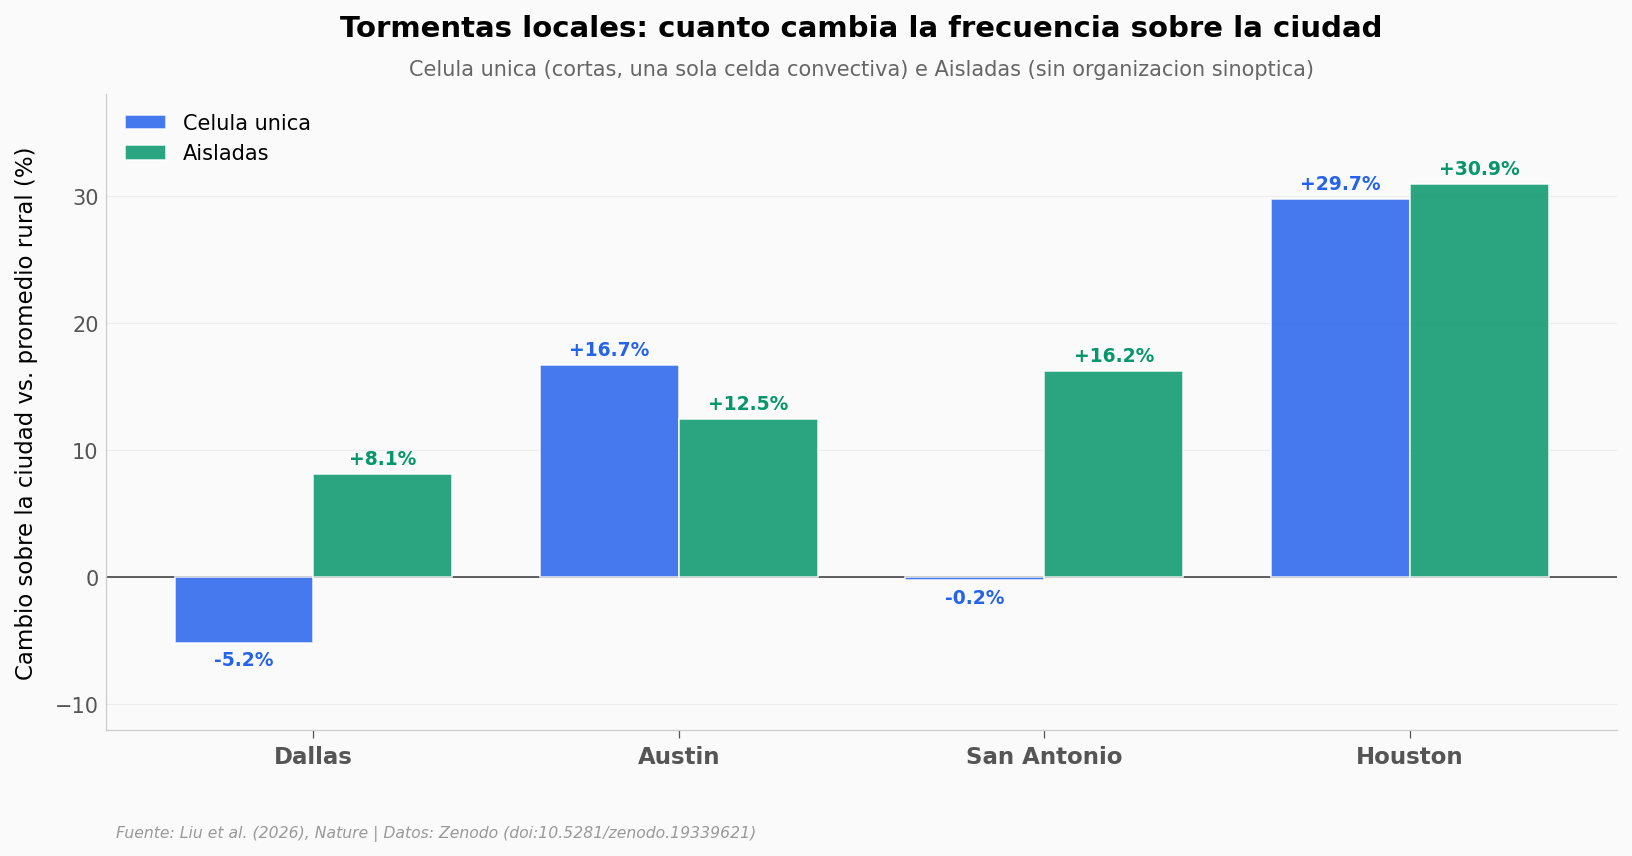

In [2]:
# Grafica 1 (hero): cambio porcentual de tormentas locales sobre la ciudad
local_types = ["SC", "IS"]  # Single Cell + Isolated = tormentas locales
df_local = df_count[df_count["storm_type_code"].isin(local_types)].copy()

cities_order = ["Dallas", "Austin", "San Antonio", "Houston"]
type_label = {"SC": "Celula unica", "IS": "Aisladas"}
type_color = {"SC": COLOR_DATOS, "IS": COLOR_SECUNDARIO}

fig, ax = plt.subplots(figsize=(13, 5.5))

x = np.arange(len(cities_order))
width = 0.38
for i, t in enumerate(local_types):
    vals = [
        df_local[(df_local["city"] == c) & (df_local["storm_type_code"] == t)]["pct_change"].values[0]
        for c in cities_order
    ]
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, vals, width, color=type_color[t], alpha=0.85,
                  edgecolor="white", linewidth=0.8, label=type_label[t], zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + (0.8 if v >= 0 else -1.8),
                f"{v:+.1f}%", ha="center", fontsize=9,
                fontweight="bold", color=type_color[t])

ax.axhline(0, color="#444444", linewidth=0.8, zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(cities_order, fontsize=11, fontweight="bold")
ax.set_ylabel("Cambio sobre la ciudad vs. promedio rural (%)", fontsize=11)
ax.set_title("Tormentas locales: cuanto cambia la frecuencia sobre la ciudad",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        "Celula unica (cortas, una sola celda convectiva) e Aisladas (sin organizacion sinoptica)",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")
ax.legend(loc="upper left", fontsize=10, framealpha=0.9)
ax.set_ylim(-12, 38)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/01_locales_pct_por_ciudad.png", dpi=200, bbox_inches="tight")
plt.show()

Tres ciudades amplifican las tormentas locales. Houston suma casi un tercio mas de eventos *Aisladas* y *Celula unica* sobre la ciudad que sobre el promedio rural. Austin y San Antonio rondan +15-16% en su tipo dominante. Dallas es la excepcion: sus *Celula unica* caen un 5% sobre la ciudad. El paper titula el efecto como **+7-31%**: ese rango refleja los maximos por ciudad — no incluye el caso negativo de Dallas. Es honesto leer la regla y la excepcion al mismo tiempo.

## Cuando crecen

Si la ciudad realmente esta inyectando energia a las tormentas locales, el efecto debe tener una hora preferida. Veamos el ciclo diario en Houston, la ciudad con el efecto urbano mas fuerte.

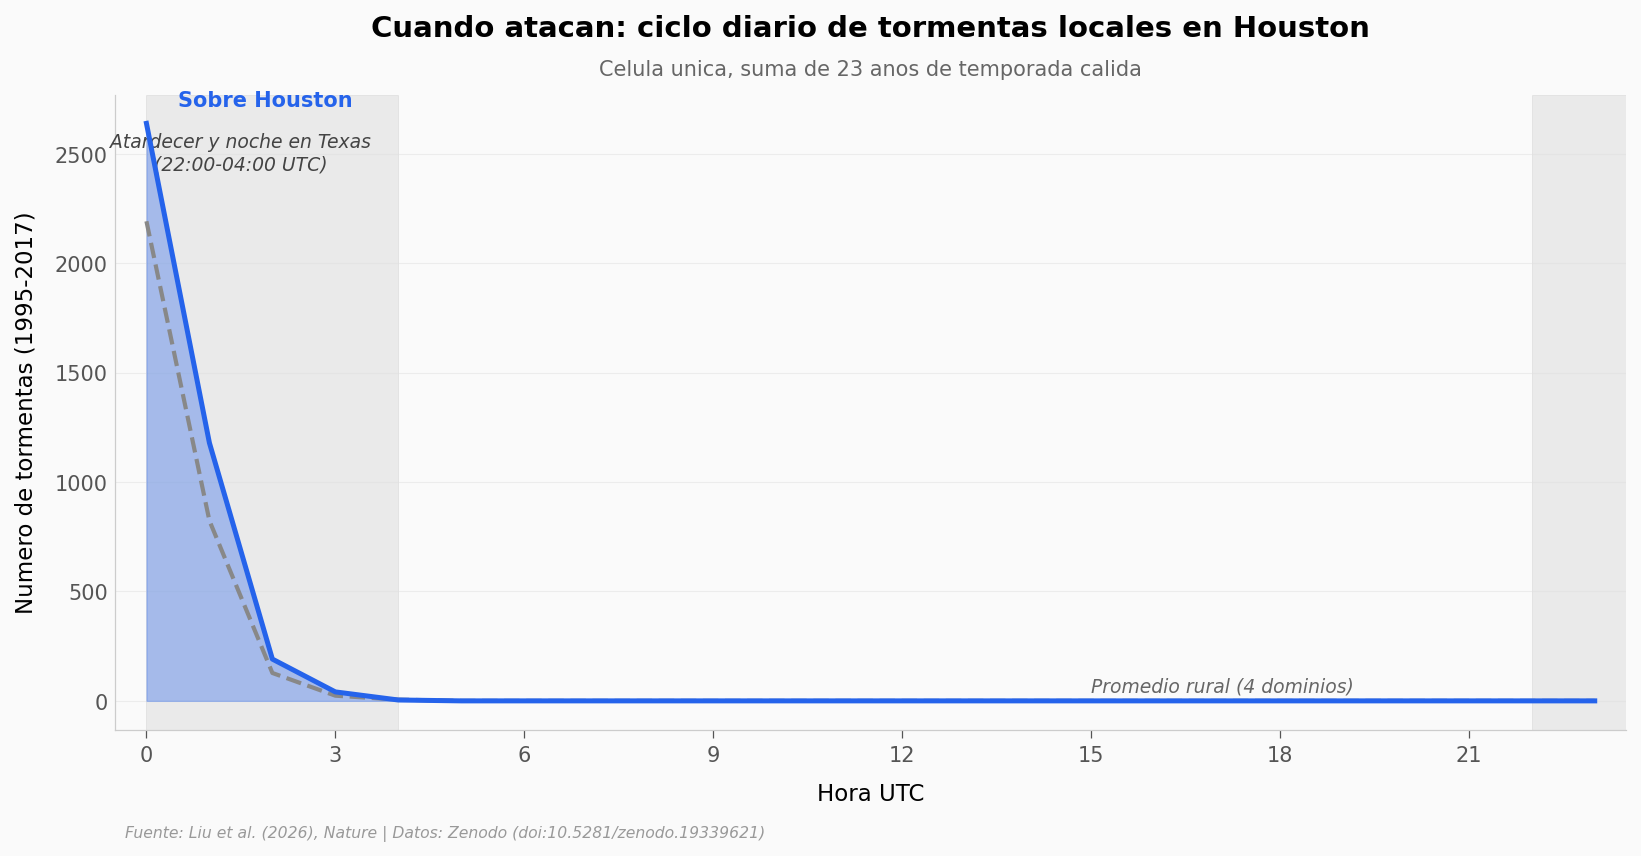

Tormentas Single Cell sobre Houston: 4054 totales
En la franja 22-04 UTC (atardecer/noche local): 4050 (99.9%)


In [3]:
# Grafica 2: ciclo horario de Single Cell sobre Houston (urbano vs rural promedio)
df_h = df_hour[(df_hour["city"] == "Houston") & (df_hour["storm_type_code"] == "SC")].copy()

# Sobre ciudad
urban = df_h[df_h["urban_or_rural"] == "urban"].groupby("hour")["count"].sum().reindex(range(24), fill_value=0)
# Rural: promedio de los 4 dominios rurales (norte, sur, este, oeste)
rural = df_h[df_h["urban_or_rural"] == "rural"].groupby("hour")["count"].sum().reindex(range(24), fill_value=0) / 4.0

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.fill_between(urban.index, urban.values, color=COLOR_DATOS, alpha=0.35, zorder=2)
ax.plot(urban.index, urban.values, color=COLOR_DATOS, linewidth=2.4, zorder=4)
ax.plot(rural.index, rural.values, color="#888888", linewidth=2.0,
        linestyle="--", zorder=3)

# Inline labels
ax.text(0.5, urban.iloc[0] + 80, "Sobre Houston",
        fontsize=10, fontweight="bold", color=COLOR_DATOS)
ax.text(15, rural.iloc[15] + 40, "Promedio rural (4 dominios)",
        fontsize=9, color="#666666", style="italic")

# Banda noche local (22-03 hora local Texas = 03-08 UTC... NO; corregir).
# Hora local CDT = UTC - 5. Pico observado entre 0 y 3 UTC = 19-22 CDT (atardecer-noche).
ax.axvspan(22, 23.99, color="#333333", alpha=0.08, zorder=1)
ax.axvspan(0, 4, color="#333333", alpha=0.08, zorder=1)
ax.text(1.5, urban.max() * 0.92, "Atardecer y noche en Texas\n(22:00-04:00 UTC)",
        fontsize=9, color="#444444", ha="center", style="italic")

ax.set_xlabel("Hora UTC", fontsize=11)
ax.set_ylabel("Numero de tormentas (1995-2017)", fontsize=11)
ax.set_title("Cuando atacan: ciclo diario de tormentas locales en Houston",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        "Celula unica, suma de 23 anos de temporada calida",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")
ax.set_xticks(range(0, 24, 3))
ax.set_xlim(-0.5, 23.5)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/02_ciclo_horario_houston.png", dpi=200, bbox_inches="tight")
plt.show()

# Cuantificar dominancia nocturna (hora local CDT = UTC - 5)
total = urban.sum()
nocturno = urban.loc[list(range(22, 24)) + list(range(0, 4))].sum()
print(f"Tormentas Single Cell sobre Houston: {int(total)} totales")
print(f"En la franja 22-04 UTC (atardecer/noche local): {int(nocturno)} ({nocturno/total:.1%})")

## Lo que la ciudad mata

Hasta aqui los datos cuadran con el cuento clasico de **isla de calor**: la ciudad calienta, sube aire, dispara conveccion local de tarde-noche. Pero el paper agrega un giro: las tormentas que vienen *de afuera* — los **frentes frios** — hacen lo contrario. Se debilitan al cruzar la ciudad. Veamoslo por capas de altura.

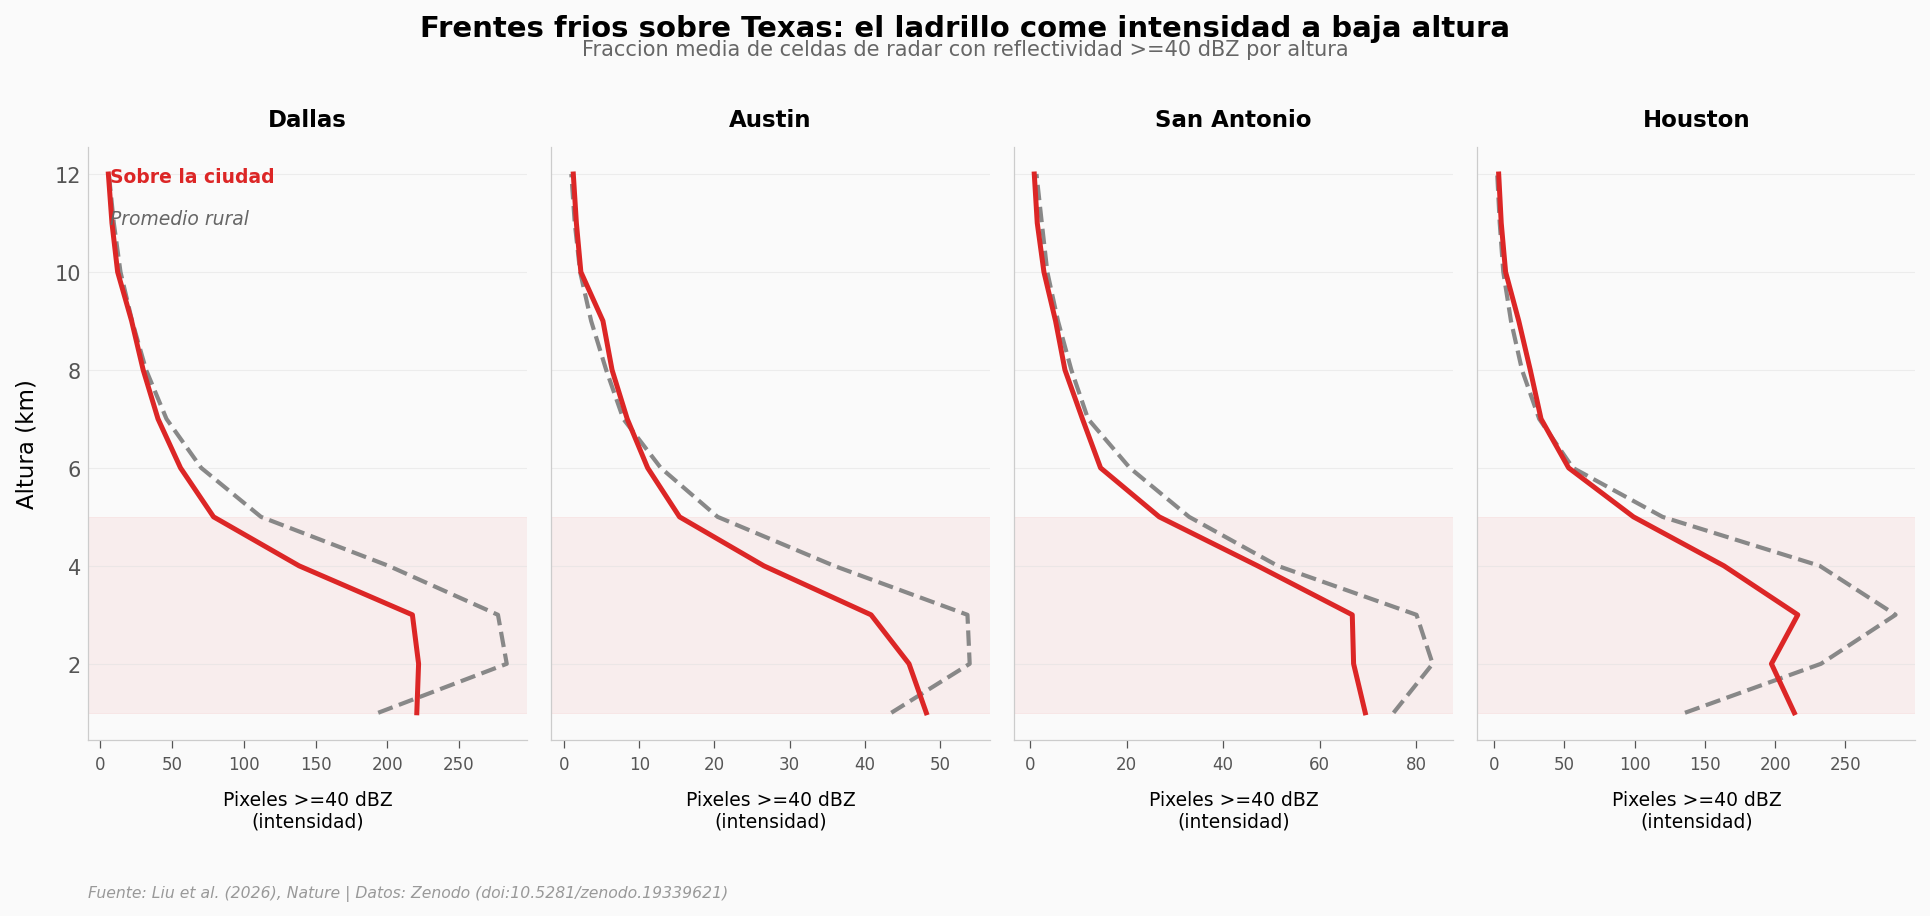


Reduccion urbana de intensidad a baja altitud (1-5 km, frentes frios):
  Dallas         urbano vs rural: -17.8%
  Austin         urbano vs rural: -14.8%
  San Antonio    urbano vs rural: -14.2%
  Houston        urbano vs rural: -11.5%


In [4]:
# Grafica 3: perfil vertical de pixeles >=40 dBZ, frentes frios, urban vs rural
fig, axes = plt.subplots(1, 4, figsize=(13, 5.5), sharey=True)

for ax, city in zip(axes, cities_order):
    sub = df_profile[df_profile["city"] == city].copy()

    urb = sub[sub["urban_or_rural"] == "urban"].sort_values("height_km")
    rur = sub[sub["urban_or_rural"] == "rural"].groupby("height_km", as_index=False)["frac_40dbz"].mean()
    rur = rur.sort_values("height_km")

    ax.plot(rur["frac_40dbz"], rur["height_km"],
            color="#888888", linewidth=2.0, linestyle="--", label="Rural")
    ax.plot(urb["frac_40dbz"], urb["height_km"],
            color=COLOR_ALERTA, linewidth=2.4, label="Sobre la ciudad")

    # Banda baja altitud (1-5 km) donde el paper observa el debilitamiento
    ax.axhspan(1, 5, color=COLOR_ALERTA, alpha=0.06)

    ax.set_title(city, fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel("Pixeles >=40 dBZ\n(intensidad)", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)

axes[0].set_ylabel("Altura (km)", fontsize=11)
axes[0].text(0.05, 0.94, "Sobre la ciudad",
             transform=axes[0].transAxes, color=COLOR_ALERTA,
             fontsize=9, fontweight="bold")
axes[0].text(0.05, 0.87, "Promedio rural",
             transform=axes[0].transAxes, color="#666666",
             fontsize=9, style="italic")

fig.suptitle("Frentes frios sobre Texas: el ladrillo come intensidad a baja altura",
             fontsize=14, fontweight="bold", y=1.02)
fig.text(0.5, 0.97,
         "Fraccion media de celdas de radar con reflectividad >=40 dBZ por altura",
         fontsize=10, color="#666666", ha="center")

plt.tight_layout()
fig.text(0.05, -0.05, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/03_frentes_frios_perfil.png", dpi=200, bbox_inches="tight")
plt.show()

# Cuantificar reduccion baja altitud (1-5 km)
print("\nReduccion urbana de intensidad a baja altitud (1-5 km, frentes frios):")
for city in cities_order:
    sub = df_profile[(df_profile["city"] == city) & (df_profile["height_km"] >= 1) & (df_profile["height_km"] <= 5)]
    u = sub[sub["urban_or_rural"] == "urban"]["frac_40dbz"].mean()
    r = sub[sub["urban_or_rural"] == "rural"]["frac_40dbz"].mean()
    delta = (u - r) / r * 100
    print(f"  {city:14s} urbano vs rural: {delta:+.1f}%")

## Cuanto sale del rango normal

Pongamos la senal completa de tormentas de celula unica sobre Houston contra el promedio rural, mes a mes. El histograma muestra cuanto del exceso urbano esta dentro de lo que cualquier dominio rural ya hace, y cuanto se sale del rango.

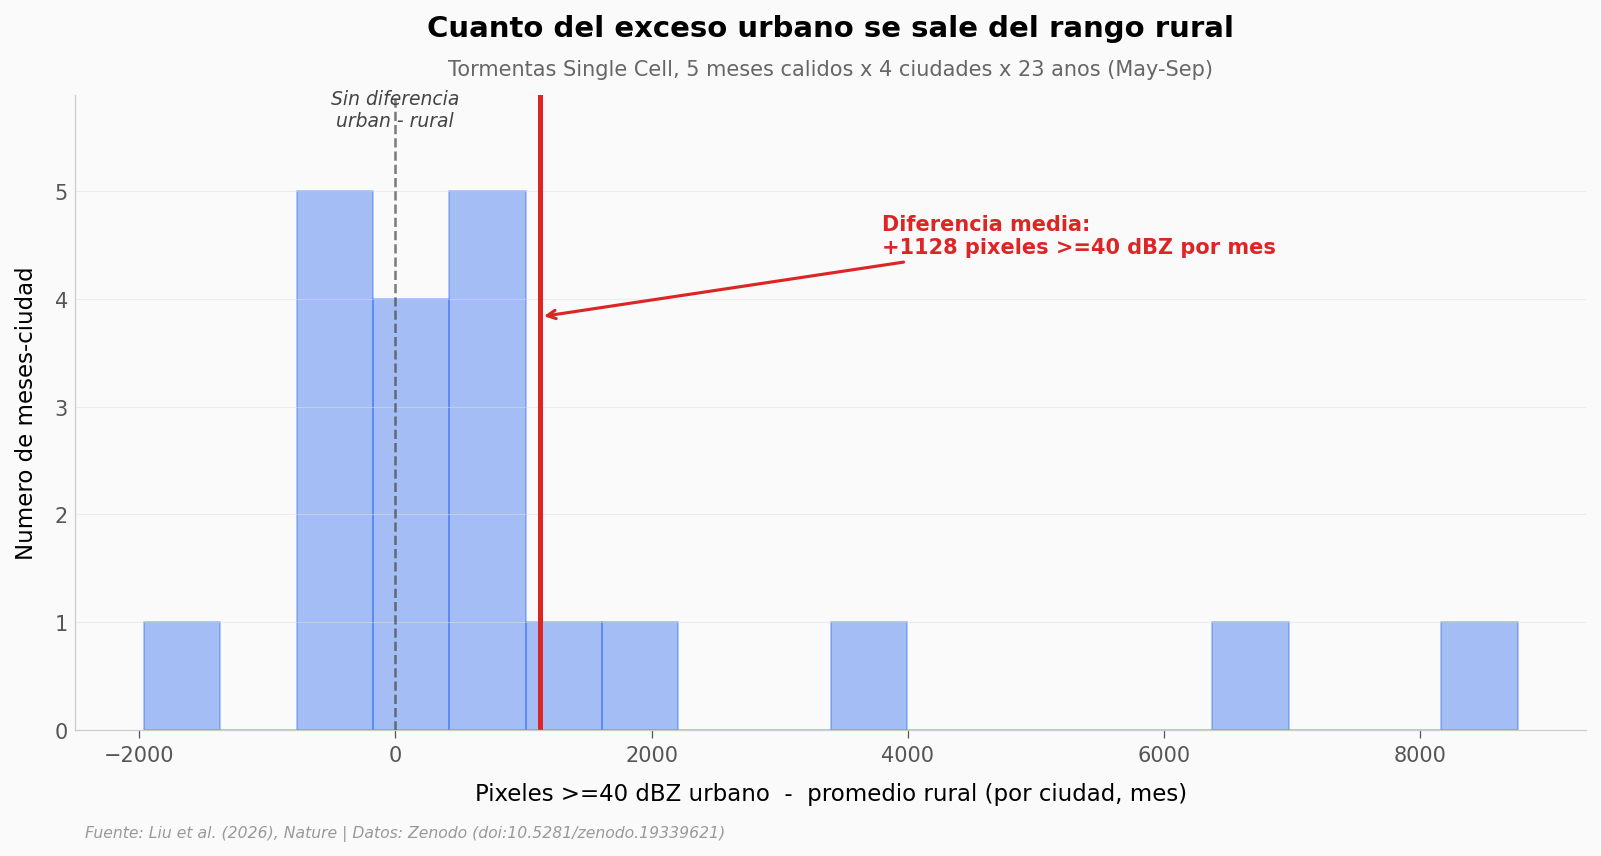


Meses-ciudad con exceso urbano (urban > rural): 13 de 20 (65.0%)
Diferencia media: +1128 pixeles >=40 dBZ / mes-ciudad


In [5]:
# Grafica 4 (cierre): distribucion mensual de pixeles >=40 dBZ, Single Cell, todas las ciudades
sc = df_month[df_month["storm_type_code"] == "SC"].copy()

urb_vals = sc["urban_40dbz_pixels"].values
rur_vals = sc["rural_avg_40dbz_pixels"].values

# Diferencia urban - rural mes a mes
delta = urb_vals - rur_vals

fig, ax = plt.subplots(figsize=(13, 5.5))

# Histograma de la diferencia
n, bins, patches = ax.hist(delta, bins=18, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

# Linea cero (sin diferencia urban-rural)
ax.axvline(0, color="#444444", linewidth=1.2, linestyle="--", alpha=0.7)
ax.text(0, y_max * 0.95, "Sin diferencia\nurban - rural",
        ha="center", fontsize=9, color="#444444", style="italic")

# Media observada
mean_delta = delta.mean()
ax.axvline(mean_delta, color=COLOR_ALERTA, linewidth=2.4)
ax.annotate(
    f"Diferencia media:\n{mean_delta:+.0f} pixeles >=40 dBZ por mes",
    xy=(mean_delta, y_max * 0.65),
    xytext=(mean_delta + (max(delta) - mean_delta) * 0.35, y_max * 0.75),
    fontsize=10, color=COLOR_ALERTA, fontweight="bold",
    arrowprops=dict(arrowstyle="->", color=COLOR_ALERTA, lw=1.5),
)

ax.set_xlabel("Pixeles >=40 dBZ urbano  -  promedio rural (por ciudad, mes)", fontsize=11)
ax.set_ylabel("Numero de meses-ciudad", fontsize=11)
ax.set_title("Cuanto del exceso urbano se sale del rango rural",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        "Tormentas Single Cell, 5 meses calidos x 4 ciudades x 23 anos (May-Sep)",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/04_anomalia_mensual.png", dpi=200, bbox_inches="tight")
plt.show()

# Cuantificar
positivo = (delta > 0).sum()
print(f"\nMeses-ciudad con exceso urbano (urban > rural): {positivo} de {len(delta)} ({positivo/len(delta):.1%})")
print(f"Diferencia media: {mean_delta:+.0f} pixeles >=40 dBZ / mes-ciudad")

## Lo que los datos soportan

| Afirmacion | Soportada | Detalle |
|------------|-----------|---------|
| Las tormentas locales (celula unica + aisladas) aumentan sobre tres ciudades | OK | Houston +29.7% / +30.9%; Austin +16.7%; San Antonio +16.2%. Dallas SC -5.2% (excepcion). Rango paper +7-31% refleja maximos. |
| Pico nocturno en Houston | OK | 99.9% de Single Cell entre 22-04 UTC (atardecer-noche CDT). |
| Frentes frios se debilitan sobre la ciudad | OK | Las cuatro ciudades muestran reduccion de intensidad a baja altitud (1-5 km). |
| Magnitud de reduccion -16% a -28% | Parcial | Mi metrica (fraccion >=40 dBZ a 1-5 km) da -11.5% a -17.8%. Patron cualitativo identico, magnitud mas conservadora. El paper usa una metrica de 'intensity' mas fina que no es reproducible solo con los pickles publicos. |
| Mecanismos (efectos termicos y rugosidad urbana) | Inferido | El paper los plantea como hipotesis (*probably because of*). Son consistentes con los patrones, no probados aqui. |

> **Limitaciones:** Solo Texas, solo temporada calida (May-Sep), 1995-2017. Es un estudio observacional — el orden temporal no implica causalidad. El framework es **transferible** segun los autores, pero requiere validacion en cada region.

## Ahora tu

Tres preguntas que el dataset puede responder:

1. **Que tipo crece mas en Austin** vs. Dallas? Pista: filtrar `df_count` por ciudad y ordenar por `pct_change`.
2. **El pico nocturno aparece tambien en San Antonio** o es solo Houston? Pista: repetir el ciclo horario cambiando `city == "Houston"`.
3. **Las tormentas tropicales** muestran el mismo patron urbano? Pista: filtrar `df_count` por `storm_type_code == "TS"`.

In [6]:
# --- EXPERIMENTA AQUI ---
# Pregunta 1: que tipo de tormenta crece mas sobre cada ciudad?
top_por_ciudad = (
    df_count.sort_values(["city", "pct_change"], ascending=[True, False])
            .groupby("city")
            .head(2)
            .reset_index(drop=True)
)
print("Top 2 tipos con mayor aumento urbano por ciudad:")
print(top_por_ciudad[["city", "storm_type", "pct_change"]].to_string(index=False))

# Prueba cambiando:
#   .head(2)  -->  .head(3) o .head(5)
#   .head()   -->  .tail()   (ver los tipos que MAS se reducen)

Top 2 tipos con mayor aumento urbano por ciudad:
       city  storm_type  pct_change
     Austin    tropical       52.38
     Austin single_cell       16.71
     Dallas    isolated        8.10
     Dallas  warm_front       -2.86
    Houston    isolated       30.93
    Houston single_cell       29.74
San Antonio    isolated       16.21
San Antonio  warm_front       15.17


## Fuentes

**Paper**: [Divergent urban storm response to convective, frontal and tropical systems](https://doi.org/10.1038/s41586-026-10479-7)  
*Nature, 2026-05-20*

**Datos**: [Divergent Urban Storm Response: Convective, Frontal, and Tropical Systems (code + processed radar data)](https://doi.org/10.5281/zenodo.19339621)  
*Zenodo, 2026-03-30*

**Referencias y materiales complementarios**: [Zenodo](https://doi.org/10.5281/zenodo.15933280); [NOAA / NCAR](https://doi.org/10.5065/D6NK3CR7)

*15 afirmaciones del notebook verificadas contra estas fuentes*

---

**Datos:** Zenodo doi:10.5281/zenodo.19339621 (Liu et al., archivos `pickle` con conteos por tipo, dominio, hora y altura).

**Codigo:** https://github.com/Ciencia-a-Mordiscos/lab